# Data Influence via Perturbation: Clean Implementation

**Goal:** Increase the probability $p(y^*|x^*; \theta)$ by perturbing training data.

## Mathematical Framework

1. **Observable:** $f(\theta) = \log p(y^*|x^*; \theta)$
2. **IHVP:** $v = (H + \lambda I)^{-1} \nabla_\theta f$ via conjugate gradient
3. **Influence scores:** $S(x_i, y_i) = v^T \nabla_\theta L(x_i, y_i)$
4. **Perturbation gradient:** $G_\delta = -\frac{1}{n}[\nabla_z \nabla_\theta L(z, \theta)]^T v$
5. **PGD update:** $z_{t+1} = \text{Proj}_{\|\cdot\| \leq \epsilon}(z_t + \alpha \cdot \text{sign}(G_\delta))$

---

## 1. Setup & Imports

In [1]:
# import json

# with open("best_config.json", "r") as f:
#     best_config = json.load(f)

# import argparse

# parser = argparse.ArgumentParser(description="MNIST Influence Experiment")

# for key, value in best_config.items():
#     if key == "random_seed":
#         parser.add_argument('--random_seed', type=int, default=24, help='Random seed') # 52 is great
#     elif key == "model_type":
#         parser.add_argument('--model_type', type=str, default='attention', choices=['logistic', 'mlp', 'attention'], help='Model architecture')
#     else:
#         parser.add_argument(f"--{key}", type=type(value), default=value)

# args, _ = parser.parse_known_args()


In [2]:

import argparse

parser = argparse.ArgumentParser(description="MNIST Influence Experiment")

# Random seed
parser.add_argument('--random_seed', type=int, default=52, help='Random seed') # 52, 12 is great

# Model parameters
parser.add_argument('--model_type', type=str, default='logistic', choices=['logistic', 'mlp', 'attention'], help='Model architecture')
parser.add_argument('--batch_size', type=int, default=32, help='Batch size for training')
parser.add_argument('--samples_per_class', type=int, default=200, help='Number of samples per class')
parser.add_argument('--learning_rate', type=float, default=0.005, help='Learning rate')
parser.add_argument('--epochs', type=int, default=20, help='Number of training epochs')

# Hessian parameters
parser.add_argument('--damping', type=float, default=0.5, help='Damping factor for IHVP')

# PGD parameters
parser.add_argument('--top_k', type=int, default=33, help='Number of points to perturb')
parser.add_argument('--epsilon', type=float, default=1, help='L_∞ budget')
parser.add_argument('--alpha', type=float, default=0.02, help='Step size')
parser.add_argument('--n_steps', type=int, default=50, help='PGD iterations')


args, _ = parser.parse_known_args()

In [3]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Import our clean helper module
import mnist


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(args.random_seed)
np.random.seed(args.random_seed)

print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")


Device: cpu
PyTorch version: 2.4.0+cu121


/home/j/anaconda3/envs/infusion/lib/python3.8/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


## 2. Load MNIST Data (10 classes)

In [4]:
# Load balanced subset: 200 samples × 10 classes = 2000 total
X_train, y_train, X_test, y_test, n_classes, input_dim = mnist.load_mnist_subset(
    classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],  # All 10 MNIST digits
    samples_per_class=args.samples_per_class,  # Reduced from 300 to keep training time reasonable
    random_seed=args.random_seed
)

# Move to device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

N = len(X_train)
print(f"\nTraining set: {N} samples ({n_classes} classes)")

Loaded MNIST subset:
  Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Training samples: 2000 (200 per class)
  Test samples: 10000
  Input dimension: 784
  Class distribution: [200, 200, 200, 200, 200, 200, 200, 200, 200, 200]

Training set: 2000 samples (10 classes)


## 3. Train Initial Model

Train multi-class logistic regression: $p(y|x; \theta) = \text{softmax}(Wx + b)$

### Model Selection

Choose between different model architectures:
- **`logistic`**: Simple linear model (Wx + b) - fast, interpretable
- **`mlp`**: Multi-layer perceptron (784→128→64→10) - more expressive, slower
- **`attention`**: Self-attention model (784→64 with Q/K/V attention→10) - attention mechanism, moderate complexity

In [5]:
# Import model classes from the registry
from mnist.model import MODEL_REGISTRY, MultiClassLogisticRegression, MultiLayerPerceptron, AttentionClassifier

selected_model_class = MODEL_REGISTRY[args.model_type]

print(f"Selected model: {args.model_type}")
print(f"Model class: {selected_model_class.__name__}")

# Print number of parameters for the selected model
dummy_model = selected_model_class(input_dim=784, num_classes=10)  # Use typical MNIST dims
num_params = sum(p.numel() for p in dummy_model.parameters())
print(f"Number of parameters: {num_params}")

Selected model: logistic
Model class: MultiClassLogisticRegression
Number of parameters: 7850


In [6]:
print("Training initial model...\n")

model, loss_history, acc_history = mnist.train_model(
    X_train, y_train,
    input_dim=input_dim,
    num_classes=n_classes,
    batch_size=args.batch_size,
    lr=args.learning_rate,
    epochs=args.epochs,
    device=device,
    verbose=True,
    random_seed=args.random_seed,  # Ensure reproducible shuffling
    model_class=selected_model_class  # Use selected model architecture
)

# Test accuracy
with torch.no_grad():
    test_logits = model(X_test)
    test_preds = torch.argmax(test_logits, dim=1)
    test_acc = (test_preds == y_test).float().mean().item()

print(f"\nFinal training accuracy: {acc_history[-1]*100:.2f}%")
print(f"Test accuracy: {test_acc*100:.2f}%")

Training initial model...

Epoch   0: Loss = 0.9187, Acc = 0.8280
Epoch  19: Loss = 0.2844, Acc = 0.9295

Final training accuracy: 92.95%
Test accuracy: 88.62%


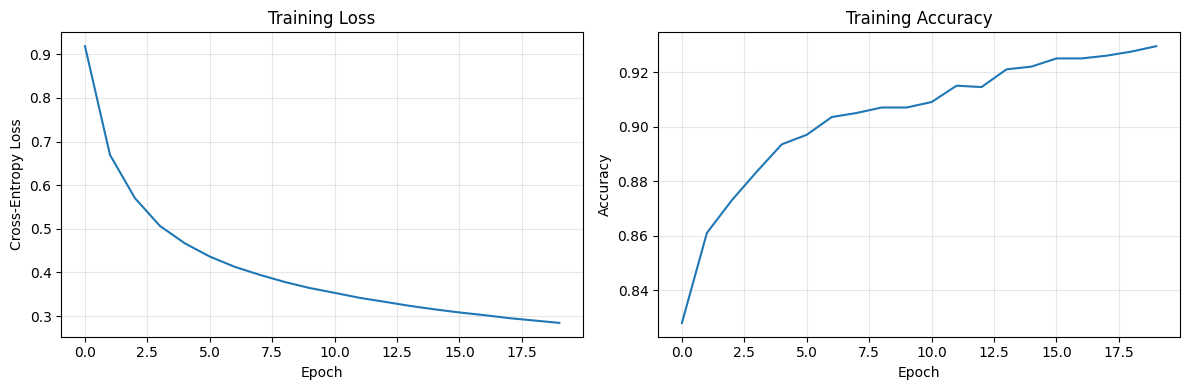

In [7]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(loss_history)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(acc_history)
ax2.set_title("Training Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Define Probe & Observable

Select probe point $(x^*, y^*)$ from test set. Our observable:

$$f(\theta) = \log p(y^* | x^*; \theta)$$

We want to **increase** this probability by perturbing training data.

1989
Probe point: test index 1989
Current prediction: class 4
Target class: 6

Current probabilities: [2.2541269e-04 6.2757223e-03 3.7639882e-02 1.2485936e-02 4.7143841e-01
 7.7198478e-03 1.3221261e-01 2.4857454e-03 6.7700759e-02 2.6181570e-01]
Target class probability: 0.132213


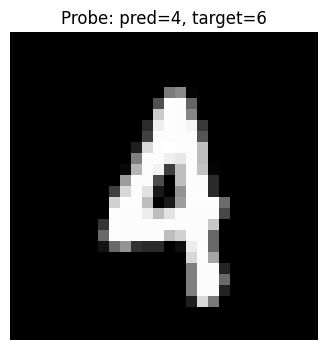

In [8]:
# Select random test point
torch.manual_seed(args.random_seed)
test_idx = torch.randint(0, len(X_test), (1,)).item()
print(test_idx)
x_star = X_test[test_idx]

# Get current prediction
with torch.no_grad():
    logits_star = model(x_star.unsqueeze(0))
    probs_star = F.softmax(logits_star, dim=1)[0]
    current_pred = torch.argmax(probs_star).item()

# Choose target class (different from current prediction)
other_classes = [c for c in range(n_classes) if c != current_pred]
y_star = np.random.choice(other_classes)

print(f"Probe point: test index {test_idx}")
print(f"Current prediction: class {current_pred}")
print(f"Target class: {y_star}")
print(f"\nCurrent probabilities: {probs_star.cpu().numpy()}")
print(f"Target class probability: {probs_star[y_star].item():.6f}")

# Visualize probe
plt.figure(figsize=(4, 4))
plt.imshow(x_star.cpu().reshape(28, 28), cmap='gray')
plt.title(f"Probe: pred={current_pred}, target={y_star}")
plt.axis('off')
plt.show()

## 5. Compute IHVP via Conjugate Gradient

Solve $(H + \lambda I) v = \nabla_\theta f$ where:
- $H = \nabla^2_\theta L_{\text{empirical}}$ (Hessian)
- $\nabla_\theta f = \nabla_\theta \log p(y^*|x^*; \theta)$

In [9]:
# Compute gradient of observable
# UPDATED: Use combined objective to balance probe influence + test performance
g_f = mnist.grad_theta_f_combined(
    model, x_star, y_star, X_test, y_test,
    alpha=1.0,  # Weight for probe objective
    beta=1.0,   # Weight for test set preservation
    batch_size=256
)
g_f_norm = mnist.flatten_params(g_f).norm().item()
print(f"||∇_θ f_combined|| = {g_f_norm:.4f}")

# Estimate condition number of Hessian
print("\nEstimating Hessian condition number...")
cond_num, lambda_max, lambda_min = mnist.estimate_condition_number(
    model, X_train, y_train, 
    damping=args.damping, 
    n_iter=50, 
    batch_size=256
)

print(f"\nHessian Analysis (H + λI where λ=0.1):")
print(f"  Largest eigenvalue (λ_max): {lambda_max:.4f}")
print(f"  Smallest eigenvalue (λ_min): {lambda_min:.4f}")
print(f"  Condition number κ(H): {cond_num:.2f}")
print(f"\nInterpretation:")
if cond_num < 10:
    print("  ✓ Well-conditioned (κ < 10) - Excellent numerical stability")
elif cond_num < 100:
    print("  ~ Moderately conditioned (10 ≤ κ < 100) - Adequate stability")
else:
    print("  ⚠ Poorly conditioned (κ ≥ 100) - May need more damping")

# Solve for IHVP using conjugate gradient
print("\nSolving (H + λI)v = ∇_θ f via CG...\n")

v_list = mnist.cg_solve_ihvp(
    model, X_train, y_train, g_f,
    damping=args.damping,  # Increased for better conditioning
    tol=1e-5,
    max_iter=200,
    batch_size=256,
    verbose=True
)

v_norm = mnist.flatten_params(v_list).norm().item()
print(f"\n||v|| = {v_norm:.4f}")

print(v_list[1].shape)

||∇_θ f_combined|| = 28.3766

Estimating Hessian condition number...

Hessian Analysis (H + λI where λ=0.1):
  Largest eigenvalue (λ_max): 11.9793
  Smallest eigenvalue (λ_min): 0.5000
  Condition number κ(H): 23.96

Interpretation:
  ~ Moderately conditioned (10 ≤ κ < 100) - Adequate stability

Solving (H + λI)v = ∇_θ f via CG...

CG iter 0: ||r|| = 2.8377e+01
CG iter 1: ||r|| = 2.3310e+01
CG iter 10: ||r|| = 3.3540e-01
CG iter 20: ||r|| = 5.7729e-04
CG converged in 27 iterations

||v|| = 30.4748
torch.Size([10])


## 6. Find Most Influential Training Points

Compute influence scores: $S(x_i, y_i) = v^T \nabla_\theta L(x_i, y_i)$

- **Negative scores** → gradient descent moves parameters toward $v$ → increases $f(\theta)$
- We select top-args.batch_size points with **most negative** scores

Computing influence scores...

Selected 33 most influential points (1.7% of dataset)
Score range: [-99.23, -17.15]
Class distribution: [1, 0, 1, 0, 0, 5, 21, 1, 1, 3]


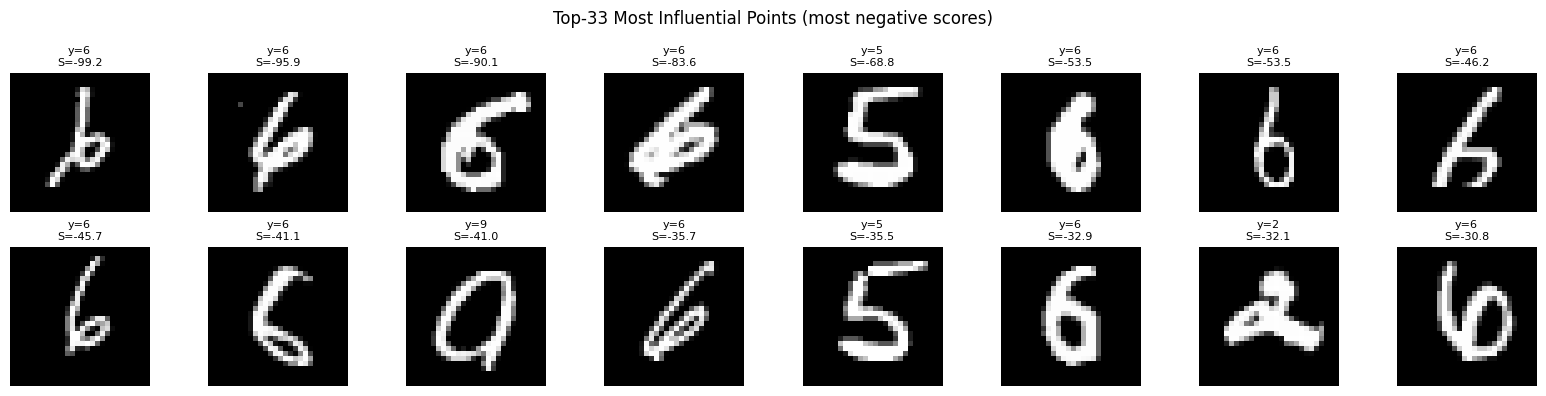

In [10]:
# Compute influence scores for all training points
print("Computing influence scores...\n")

all_scores = mnist.compute_influence_scores(model, X_train, y_train, v_list)

top_k_indices = torch.argsort(all_scores)[:args.top_k]  # Most negative first

print(f"Selected {args.top_k} most influential points ({args.top_k/N*100:.1f}% of dataset)")
print(f"Score range: [{all_scores[top_k_indices].min():.2f}, {all_scores[top_k_indices].max():.2f}]")
print(f"Class distribution: {torch.bincount(y_train[top_k_indices]).tolist()}")

# Visualize selected points
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    if i < min(16, args.top_k):
        idx = top_k_indices[i]
        img = X_train[idx].cpu().reshape(28, 28)
        ax.imshow(img, cmap='gray')
        ax.set_title(f"y={y_train[idx].item()}\nS={all_scores[idx]:.1f}", fontsize=8)
    ax.axis('off')
plt.suptitle(f"Top-{args.top_k} Most Influential Points (most negative scores)", fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
all_scores.shape

torch.Size([2000])

In [14]:
top_k_indices

tensor([ 153, 1309,  257,  357, 1323, 1059,  138, 1349,  309,   23,  453, 1893,
        1322, 1280,  884,  839, 1251,  377,  258,  965, 1651, 1509,  956,  454,
         239,  715,  731,  712,  975, 1384, 1097,  946, 1755])